# Mouse Pancreas Atlas Investigation
## Load dataset

In [ ]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


adata = read_anndata(
    'data/Hrovatin2023_preprocessed.zarr',
    X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

dask: False, backed: False
Read slot "X", store as "X"...
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


## Dataset Complexity


### Tissues

Q: tissue_type vs tissue? -> different every case

cellxgene schema

In [3]:
print(adata.obs['tissue_type'].unique())

['tissue']
Categories (1, object): ['tissue']


In [4]:
print(adata.obs['tissue'].unique())

['islet of Langerhans', 'pancreas']
Categories (2, object): ['islet of Langerhans', 'pancreas']


islet of Langerhans is a subset of pancreas

sample size per tissue

In [5]:
adata.obs['tissue'].value_counts()

tissue
islet of Langerhans    264235
pancreas                37561
Name: count, dtype: int64

### Number of Cells and Genes

In [6]:
adata

AnnData object with n_obs × n_vars = 301796 × 31202
    obs: 'batch_integration', 'dataset', 'design', 'cell_cycle_phase', 'ins_high', 'gcg_high', 'sst_high', 'ppy_high', 'cell_filtering', 'strain', 'age', 'cell_type_originalDataset_unified', 'cell_type_originalDataset', 'cell_type_reannotatedIntegrated', 'n_genes', 'mt_frac', 'doublet_score', 'log10_n_counts', 'age_approxDays', 'dataset__design__sample', 'cell_subtype_immune_reannotatedIntegrated', 'cell_subtype_endothelial_reannotatedIntegrated', 'emptyDrops_LogProb_scaled', 'cell_subtype_beta_coarse_reannotatedIntegrated', 'cell_subtype_beta_fine_reannotatedIntegrated', 'GP_1', 'GP_2', 'GP_3', 'GP_4', 'GP_5', 'GP_6', 'GP_7', 'GP_8', 'GP_9', 'GP_10', 'GP_11', 'GP_12', 'GP_13', 'GP_14', 'GP_15', 'GP_16', 'GP_17', 'GP_18', 'GP_19', 'GP_20', 'GP_21', 'GP_22', 'GP_23', 'GP_24', 'GP_25', 'GP_26', 'GP_27', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'diabetes_model', 'chemical_stress', 'GEO

### Number of Cell Types

Q: cell_type_originalDataset or cell_type_reannotatedIntegrated?

compare the columns and see how the granularity is and compare

pandas cross

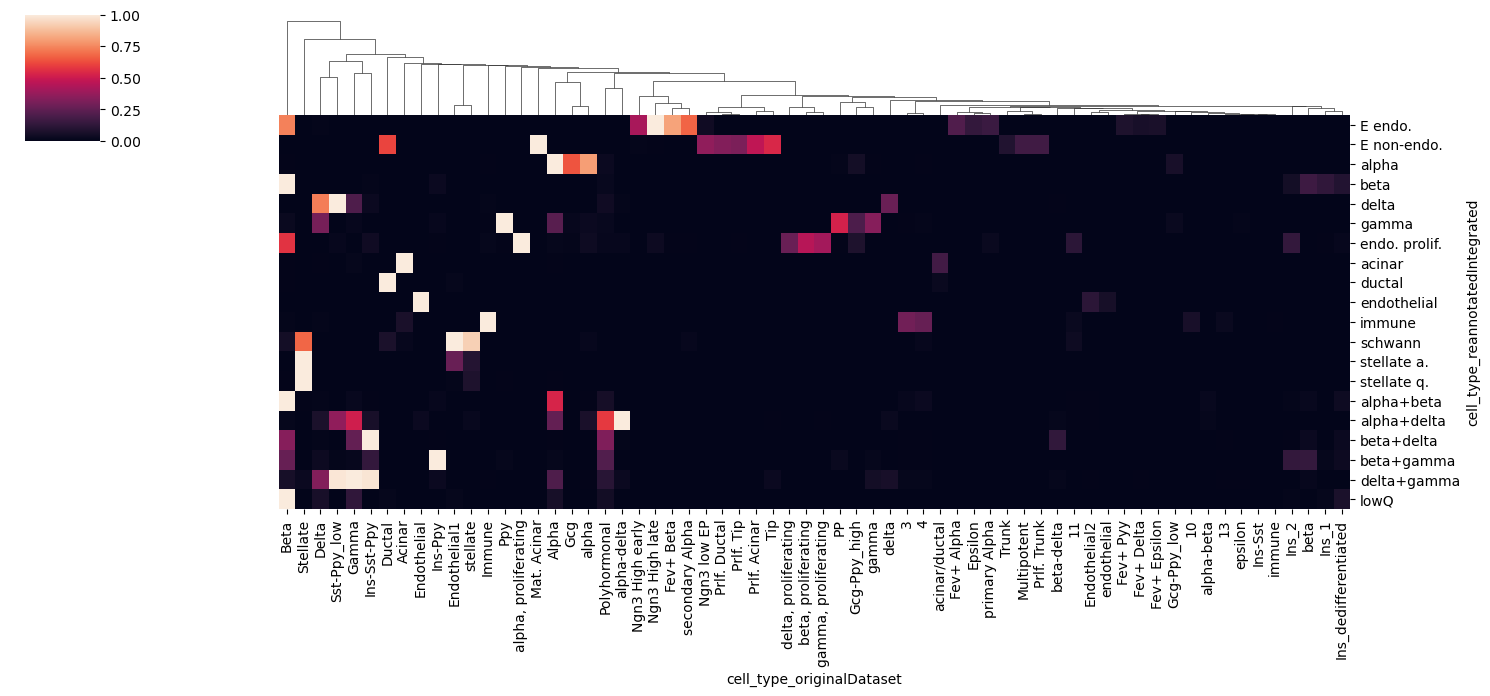

In [ ]:
ct = pd.crosstab(
    adata.obs['cell_type_originalDataset'],
    adata.obs['cell_type_reannotatedIntegrated']
)
sns.clustermap(
    ct.T,
    figsize=(15, 7),
    standard_scale=0, xticklabels=True, yticklabels=True, row_cluster=False)

In [78]:
adata.obs[['cell_type_originalDataset', 'cell_type_reannotatedIntegrated']].drop_duplicates().value_counts('cell_type_originalDataset')

cell_type_originalDataset
Beta            20
Alpha           17
Polyhormonal    17
Delta           14
Immune          13
                ..
Fev+ Epsilon     1
Fev+ Pyy         1
Prlf. Ductal     1
endothelial      1
immune           1
Name: count, Length: 64, dtype: int64

In [79]:
adata.obs[['cell_type_originalDataset', 'cell_type_reannotatedIntegrated']].drop_duplicates().value_counts('cell_type_reannotatedIntegrated')

cell_type_reannotatedIntegrated
beta             43
alpha            38
delta            34
E non-endo.      31
beta+delta       28
endo. prolif.    27
alpha+delta      26
immune           26
gamma            25
delta+gamma      24
beta+gamma       24
E endo.          22
alpha+beta       21
stellate q.      17
ductal           17
stellate a.      16
lowQ             15
schwann          11
endothelial      10
acinar            7
Name: count, dtype: int64

Here, secondary Alpha matches with alpha, which is good, but also it matches with beta, prolif., etc.

That means the orginialDataset is too broad, or too coarse.

In [9]:
adata.obs['cell_type_reannotatedIntegrated'].nunique()

20

## Batch Complexity
### Number of Batches

Q: dataset or batch_integration?

go to the paper and figure out what they considered a batch. samples? datasets? donor? 

-> Samples as batches

In [12]:
adata.obs['dataset__design__sample'].nunique()

56

is the same as:

In [10]:
adata.obs['batch_integration'].nunique()

56

Which checks out with the paper, saying that each sample is treated as a batch.

### Batch Size Imbalance

bar plot? standard deviation? distribution. 

In [ ]:

batch_sizes = adata.obs['batch_integration'].value_counts().sort_index()
mean = np.mean(batch_sizes)
std_dev = np.std(batch_sizes)
min_val = batch_sizes.min()
max_val = batch_sizes.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std_dev:.2f}")
print(f"Min batch size: {min_val}")
print(f"Max batch size: {max_val}")

Mean batch size: 5389.21
Standard deviation: 3552.77
Min batch size: 622
Max batch size: 19923


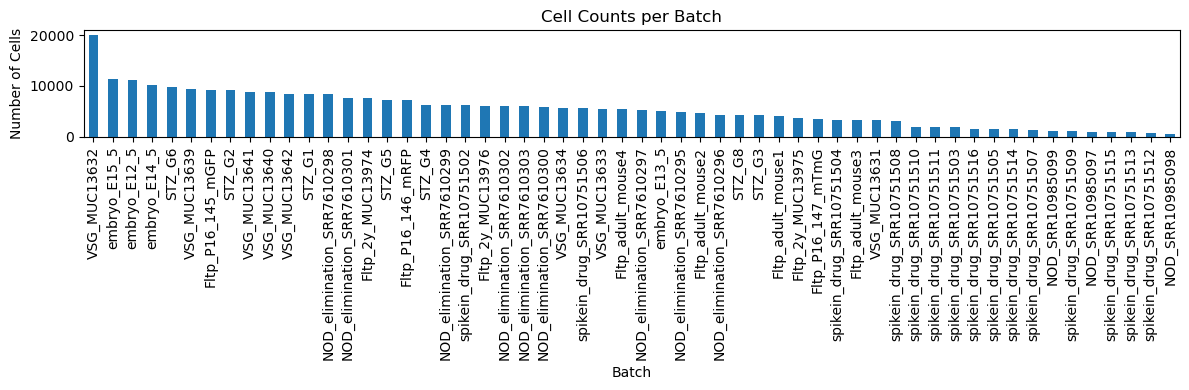

In [90]:

batch_sizes.sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.title("Cell Counts per Batch")
plt.ylabel("Number of Cells")
plt.xlabel("Batch")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Q: Is this barplot interesting?

A: Yes, we can see the distribution on one sight

### Nested Batches

If rows (dataset) matches with multiple columns (batches) but the batch matches with only one dataset -> nested batches

Multiple batches occur within a single dataset, but each batch only ever belongs to one dataset.


----

make heatmap or seaborn cluster map or sth

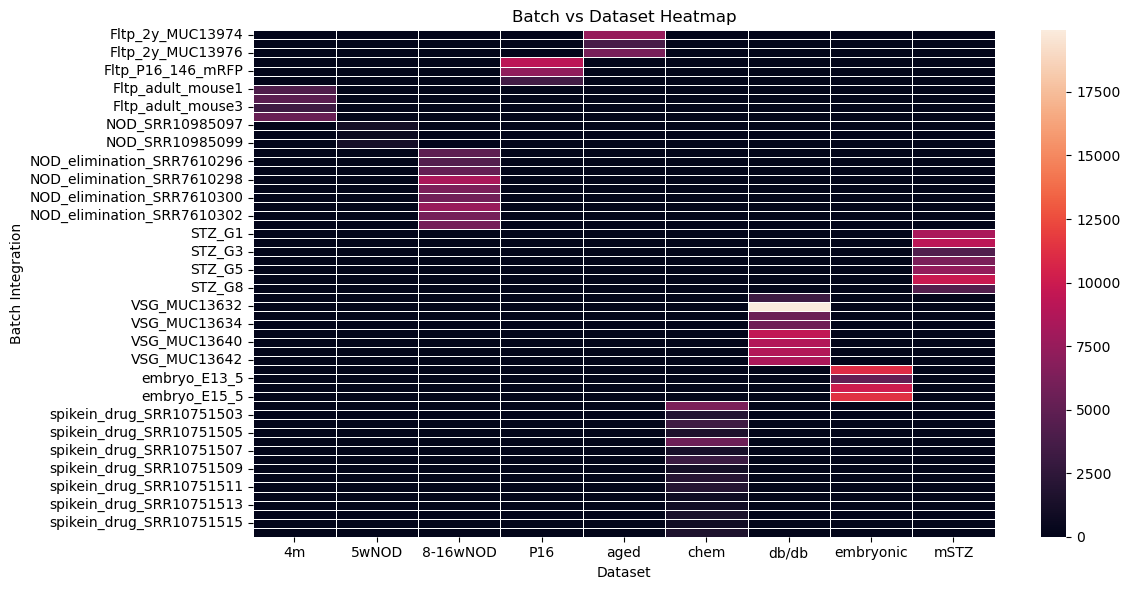

In [84]:
ct = pd.crosstab(adata.obs['batch_integration'], adata.obs['dataset'])
plt.figure(figsize=(12, 6))
sns.heatmap(ct, linewidths=0.5, annot=False)
plt.title("Batch vs Dataset Heatmap")
plt.xlabel("Dataset")
plt.ylabel("Batch Integration")
plt.tight_layout()
plt.show()

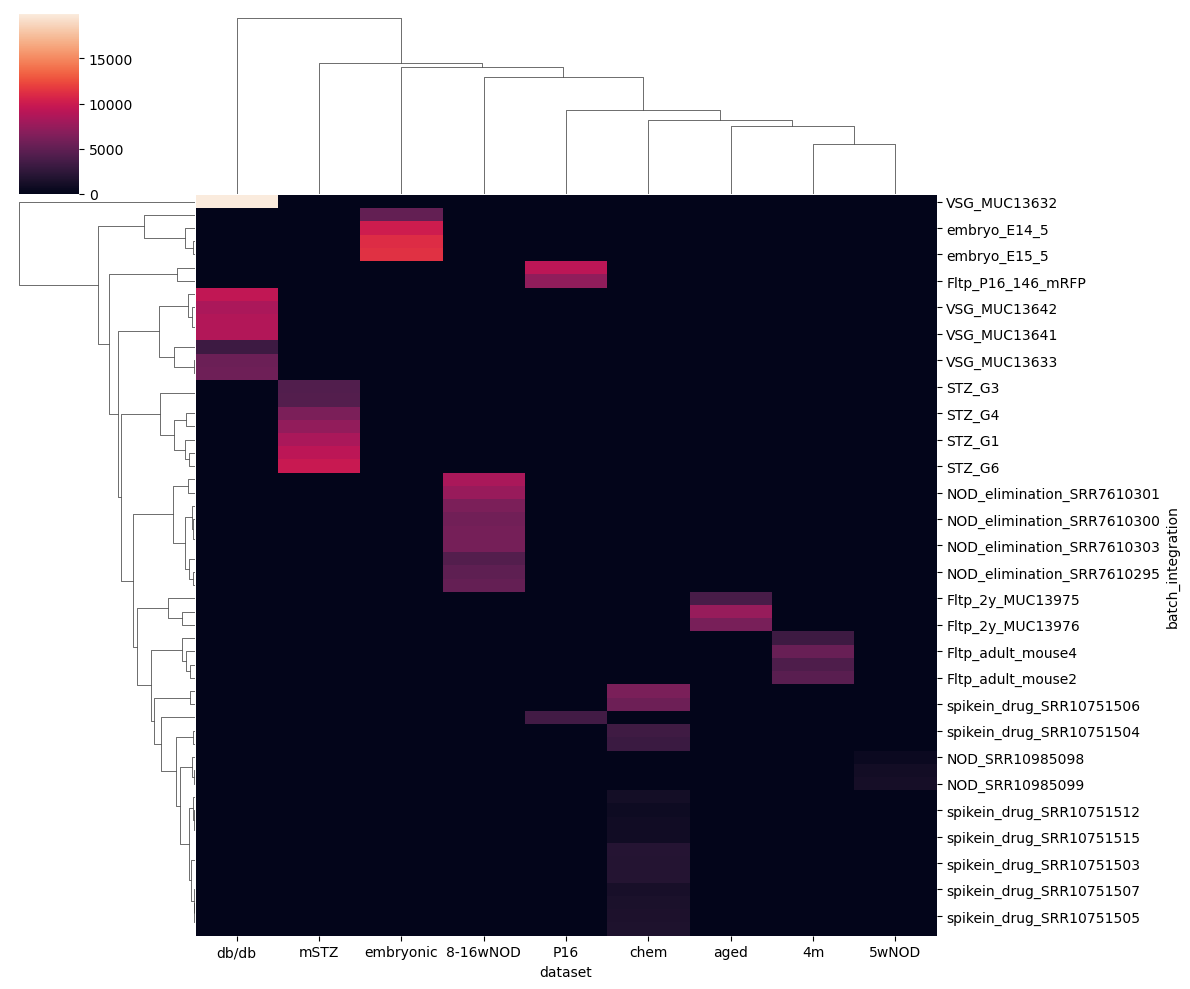

In [85]:
sns.clustermap(ct, figsize=(12, 10))


One dataset - multiple batches -> nested batch effect

In [80]:
adata.obs[['dataset', 'batch_integration']].drop_duplicates().value_counts('dataset')

dataset
chem         15
8-16wNOD      9
db/db         8
mSTZ          7
4m            4
embryonic     4
aged          3
5wNOD         3
P16           3
Name: count, dtype: int64

In [83]:
adata.obs[['dataset', 'batch_integration']].drop_duplicates().value_counts('batch_integration').head(10)

batch_integration
Fltp_2y_MUC13974     1
Fltp_2y_MUC13975     1
Fltp_2y_MUC13976     1
Fltp_P16_145_mGFP    1
Fltp_P16_146_mRFP    1
Fltp_P16_147_mTmG    1
Fltp_adult_mouse1    1
Fltp_adult_mouse2    1
Fltp_adult_mouse3    1
Fltp_adult_mouse4    1
Name: count, dtype: int64

This shows a dataset:batch 1:N relationship

### Number of Samples

In [18]:
adata.obs['dataset__design__sample'].nunique()


56

In [19]:
sample_sizes = adata.obs['dataset__design__sample'].value_counts()
print(sample_sizes)

dataset__design__sample
db/db__PF_Lepr-/-__MUC13632             19923
embryonic__E15.5__E15_5                 11303
embryonic__E12.5__E12_5                 11090
embryonic__E14.5__E14_5                 10089
mSTZ__STZ_GLP-1_estrogen__G6             9863
db/db__sham_Lepr-/-__MUC13639            9442
P16__mGFP__145_mGFP                      9221
mSTZ__STZ__G2                            9184
db/db__sham_Lepr-/-__MUC13641            8788
db/db__VSG_Lepr-/-__MUC13640             8787
db/db__VSG_Lepr-/-__MUC13642             8439
mSTZ__control__G1                        8388
8-16wNOD__14w__SRR7610298                8372
8-16wNOD__16w__SRR7610301                7564
aged__mRFP__MUC13974                     7534
mSTZ__STZ_estrogen__G5                   7280
P16__mRFP__146_mRFP                      7172
mSTZ__STZ_GLP-1__G4                      6292
8-16wNOD__14w__SRR7610299                6271
chem__A1_r1__SRR10751502                 6164
aged__mGFP__MUC13976                     6081
8-16wNOD__

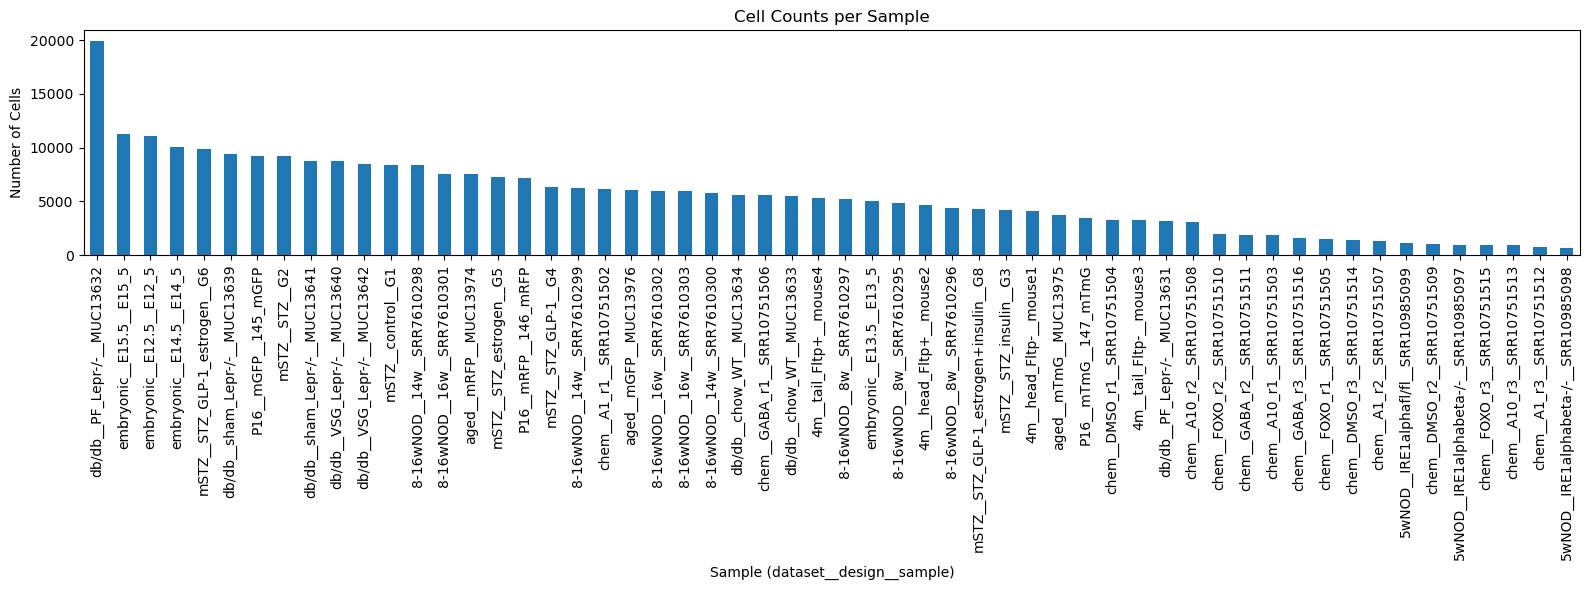

In [88]:
plt.figure(figsize=(16, 6))
sample_sizes.plot(kind='bar')
plt.title("Cell Counts per Sample")
plt.xlabel("Sample (dataset__design__sample)")
plt.ylabel("Number of Cells")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Number of Donors

Check if sample = donor. 

If each row maps to only one donor, sample = donor

maybe valuecounts instead of crosstab

check 1:N or N:N mapping

In [16]:
pd.crosstab(adata.obs['dataset__design__sample'], adata.obs['donor_id'])


donor_id,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13974,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13975,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13976,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__145_mGFP,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__146_mRFP,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__147_mTmG,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse1,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse2,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse3,mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse4,...,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751507,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751508,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751509,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751510,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751511,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751512,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751513,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751514,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751515,mouse_pancreatic_islet_atlas_Hrovatin__spikein_drug__SRR10751516
dataset__design__sample,,,,,,,,,,,,,,,,,,,,,
4m__head_Fltp+__mouse2,0,0,0,0,0,0,0,4664,0,0,...,0,0,0,0,0,0,0,0,0,0
4m__head_Fltp-__mouse1,0,0,0,0,0,0,4094,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4m__tail_Fltp+__mouse4,0,0,0,0,0,0,0,0,0,5359,...,0,0,0,0,0,0,0,0,0,0
4m__tail_Fltp-__mouse3,0,0,0,0,0,0,0,0,3236,0,...,0,0,0,0,0,0,0,0,0,0
5wNOD__IRE1alphabeta-/-__SRR10985097,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5wNOD__IRE1alphabeta-/-__SRR10985098,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5wNOD__IRE1alphafl/fl__SRR10985099,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8-16wNOD__8w__SRR7610295,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8-16wNOD__8w__SRR7610296,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


If sample =/= donor:

In [17]:
adata.obs['donor_id'].nunique()

56

### Number of Cohorts

each study would be different cohort - why?!

A cohort is a group of individuals or samples that share a common characteristic and are analyzed or tracked together in a study.

check dataset names and paper

In [94]:
adata.obs["dataset"].nunique()

9

## Annotation Quality
### Correctness of Labels -> Resolution of Annotation

cell type label vs marker genes dotplot

Q: Use canonical or computational?

look for marker genes on the paper as well focus on the cell type some times

In [ ]:
adata.obs['cell_type_reannotatedIntegrated'].unique()

['ductal', 'gamma', 'endothelial', 'immune', 'stellate q.', ..., 'alpha+beta', 'beta+gamma', 'delta+gamma', 'acinar', 'schwann']
Length: 20
Categories (20, object): ['E endo.' < 'E non-endo.' < 'alpha' < 'beta' ... 'beta+delta' < 'beta+gamma' < 'delta+gamma' < 'lowQ']


In [22]:
print(adata.obs['cell_type_reannotatedIntegrated'].unique().tolist())


['ductal', 'gamma', 'endothelial', 'immune', 'stellate q.', 'delta', 'alpha+delta', 'beta', 'E non-endo.', 'alpha', 'E endo.', 'stellate a.', 'endo. prolif.', 'beta+delta', 'lowQ', 'alpha+beta', 'beta+gamma', 'delta+gamma', 'acinar', 'schwann']


In [96]:
marker_genes_comp = {
    "ductal": ["Anxa4", "Mmp7"],
    "gamma": ["Ppy", "Chgb"],
    "endothelial": ["Pecam1", "Egfl7"],
    "immune": ["Arhgdib", "Ptprc"],
    "delta": ["Sst", "Scg5"],
    "beta": ["Ins1", "Ins2", "Scg5"],
    "alpha": ["Ttr", "Gcg"],
    "acinar": ["Pla2g1b", "Cela3a"],
    "schwann": ["Cdh19", "Scn7a"],

}

marker_genes_canon = {
    "ductal": ["Cftr", "Hpgds"],
    "endothelial": ["Cldn5", "Emcn"],
    "delta": ["Hhex"],
    "beta": ["Mafa", "Nkx6-1"],
    "alpha": ["Arx", "Irx2"],
    "schwann": ["Sox10", "Mbp"],

}

marker_genes_paper = {
    "beta": ["Ins1", "Ins2", "Nkx6-1", "Pdx1"],
    "immune": ["Rbp4", "Cd81", "Mafb"],
}
adata.var['gene_symbol'] = adata.var['feature_name'].str.split('_').str[0]



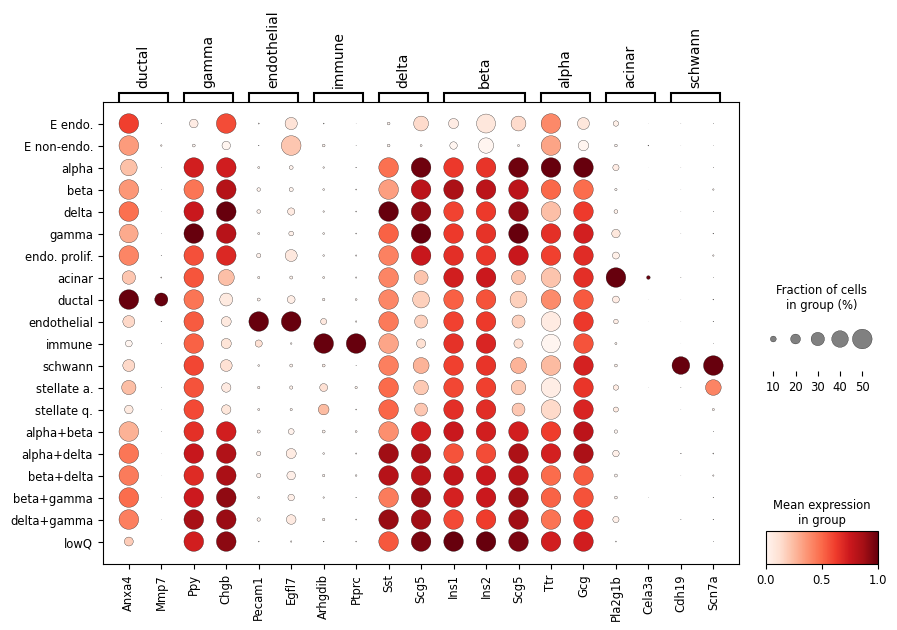

In [ ]:
sc.pl.dotplot(
    adata,
    var_names=marker_genes_comp,
    groupby='cell_type_reannotatedIntegrated',
    gene_symbols='gene_symbol',
    standard_scale='var',
    dot_max=0.5,
    figsize=(10, 6)
)

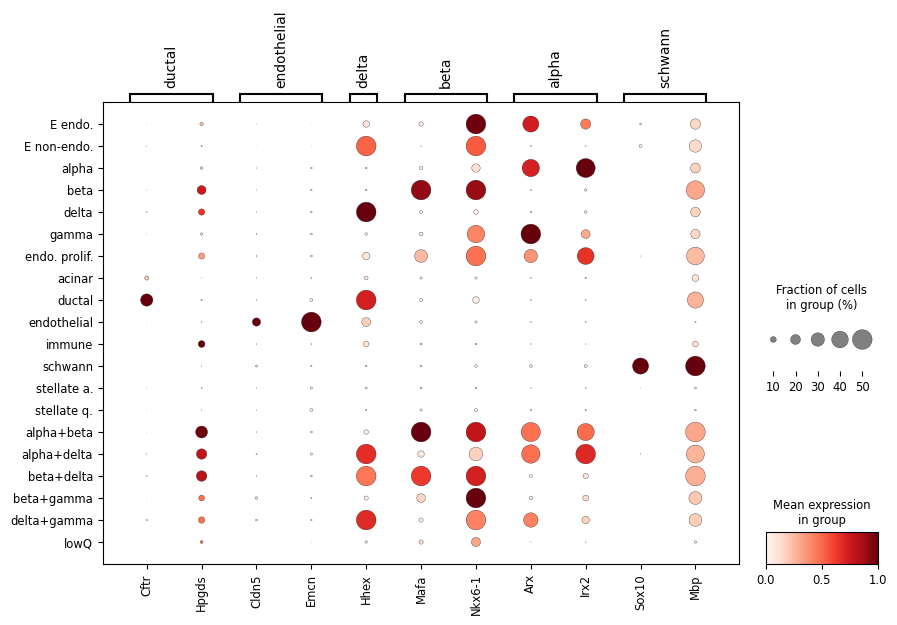

In [50]:
sc.pl.dotplot(
    adata,
    var_names=marker_genes_canon,
    groupby='cell_type_reannotatedIntegrated',
    gene_symbols='gene_symbol',
    standard_scale='var',
    dot_max=0.5,
    figsize=(10, 6)
)

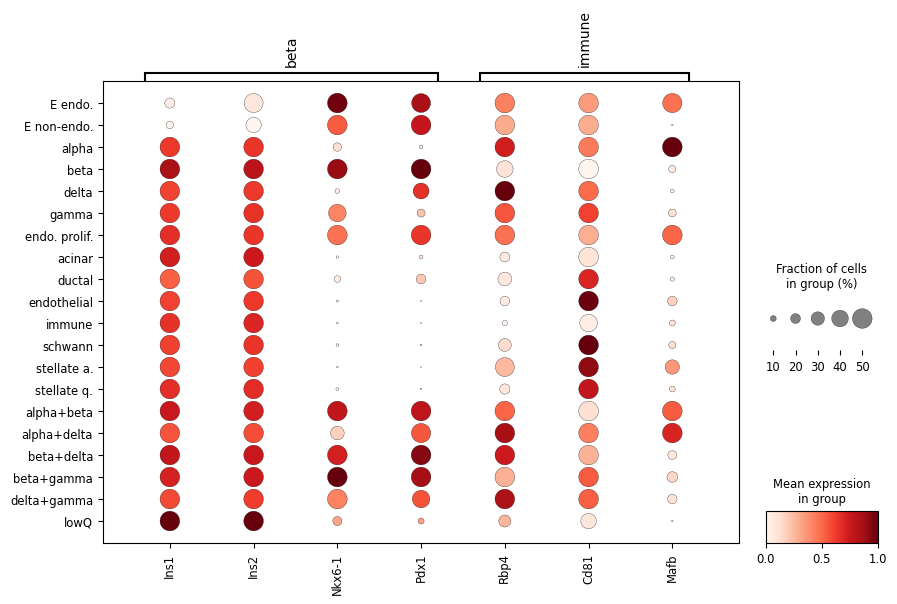

In [97]:
sc.pl.dotplot(
    adata,
    var_names=marker_genes_paper,
    groupby='cell_type_reannotatedIntegrated',
    gene_symbols='gene_symbol',
    standard_scale='var',
    dot_max=0.5,
    figsize=(10, 6)
)

### Granularity of Cell Types

Q: again, cell_type_originalDatset or cell_type_reannotatedIntegrated?

A: use the harmonised label, reannotated

plot all of the columns on umap and seeee like beta cells

plot umap with integrated

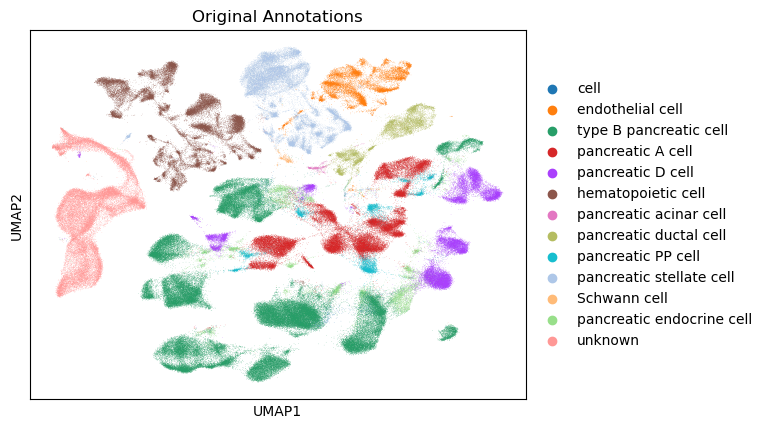

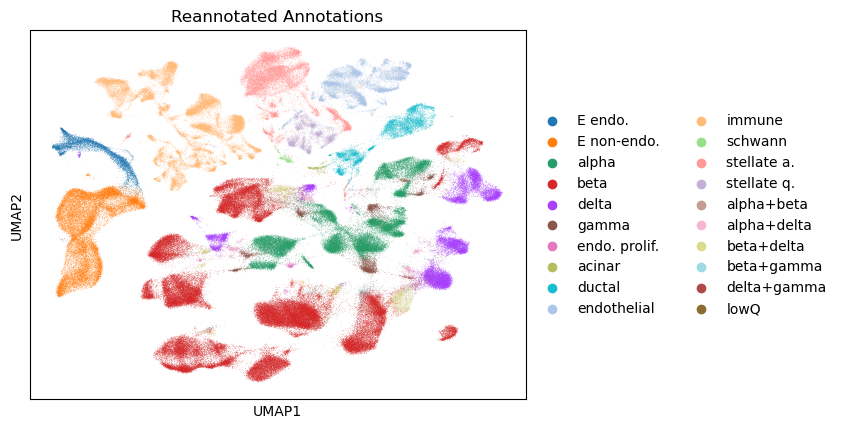

In [98]:
sc.pl.umap(adata, color='cell_type', title='Original Annotations')
sc.pl.umap(adata, color='cell_type_reannotatedIntegrated', title='Reannotated Annotations')

-> Original is more detailed, so it's coarse?


subset each cells with the finer labels?

create a new column with pandas 

rename the ones that are not none in the beta column

## Metadata Completeness
### Spatial Context

blood - doesn't matter

but skin - matters

anatomical location

check the paper

--> No anatomical context mentioned

### Existence of Embedding

In [21]:
print(adata.obsm)


AxisArrays with keys: X_integrated_umap, X_integrated_umap_beta, X_pca, X_umap


-> has umap and pca